In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip '/content/drive/MyDrive/experience 3.zip'

Streaming output truncated to the last 5000 lines.
  inflating: experience 3/Group k/Alf_Isolated/AHCR_00033_Alf_Isolated_15.jpg  
  inflating: experience 3/Group k/Alf_Isolated/AHCR_00033_Alf_Isolated_6.jpg  
  inflating: experience 3/Group k/Alf_Isolated/AHCR_00033_Alf_Isolated_7.jpg  
  inflating: experience 3/Group k/Alf_Isolated/AHCR_00034_Alf_Isolated_14.jpg  
  inflating: experience 3/Group k/Alf_Isolated/AHCR_00034_Alf_Isolated_15.jpg  
  inflating: experience 3/Group k/Alf_Isolated/AHCR_00034_Alf_Isolated_6.jpg  
  inflating: experience 3/Group k/Alf_Isolated/AHCR_00034_Alf_Isolated_7.jpg  
  inflating: experience 3/Group k/Alf_Isolated/AHCR_00035_Alf_Isolated_14.jpg  
  inflating: experience 3/Group k/Alf_Isolated/AHCR_00035_Alf_Isolated_15.jpg  
  inflating: experience 3/Group k/Alf_Isolated/AHCR_00035_Alf_Isolated_6.jpg  
  inflating: experience 3/Group k/Alf_Isolated/AHCR_00035_Alf_Isolated_7.jpg  
  inflating: experience 3/Group k/Alf_Isolated/AHCR_00036_Alf_Isolated_14.j

In [3]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import cv2
import os
import tensorflow as tf


In [ ]:
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

img_width, img_height = 100, 100
data_dir = "/content/experience 3"
def load_images(data_dir):
    images, labels = [], []
    group_names = sorted(os.listdir(data_dir))

    for label, group_name in enumerate(group_names):
        group_path = os.path.join(data_dir, group_name)

        if os.path.isdir(group_path):
            for root, _, files in os.walk(group_path):
                for img_file in files:
                    img_path = os.path.join(root, img_file)

                    try:

                        if not img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                            continue

                        img = tf.keras.preprocessing.image.load_img(
                            img_path, target_size=(img_width, img_height), color_mode='grayscale'
                        )
                        img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
                        images.append(img_array)
                        labels.append(label)
                    except Exception as e:
                        print(f"⚠️ error in load image {img_file} in {group_name}: {e}")

    if len(images) == 0:
        raise ValueError(" couldnt load any image")

    return np.array(images), np.array(labels)

images, labels = load_images(data_dir)

if len(images.shape) == 3:
    images = np.expand_dims(images, axis=-1)

num_classes = len(np.unique(labels))
labels = to_categorical(labels, num_classes)

x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42, stratify=labels)

print(f"training features {x_train.shape[0]}")
print(f"testing features  {x_test.shape[0]}")
print(f"📂Groups: {num_classes}")
print(f"🖼️ image shape  {x_train.shape}")


training features 33924
testing features  8482
📂Groups: 11
🖼️ image shape  (33924, 100, 100, 1)


In [ ]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.02,
    height_shift_range=0.02,
    shear_range=0.15,
    zoom_range=0.2,
    fill_mode='nearest'
)

train_generator = datagen.flow(x_train, y_train, batch_size=35)

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, GlobalAveragePooling2D, Dropout

input_layer = Input(shape=(100, 100, 1))

x = Conv2D(3, (3, 3), padding="same", activation="relu")(input_layer)
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(100, 100, 3))
x = base_model(x)

x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)  # Dropout before dense layers
x = Dense(128, activation="relu")(x)
output_layer = Dense(11, activation="softmax")(x)

model = Model(inputs=input_layer, outputs=output_layer)

for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

print(model.summary())


<ipython-input-6-a92ed5544e62>:9: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(100, 100, 3))


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 100, 100, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 100, 100, 3)         │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 4, 4, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 11)                  │           1,419 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,423,401 (9.24 MB)

 Trainable params: 165,417 (646.16 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

None


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'digit_recognition_model_xception.keras',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1
)
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


969/970 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.4548 - loss: 1.5843
Epoch 1: val_accuracy improved from -inf to 0.64796, saving model to digit_recognition_model_xception.keras
970/970 ━━━━━━━━━━━━━━━━━━━━ 71s 59ms/step - accuracy: 0.4550 - loss: 1.5838 - val_accuracy: 0.6480 - val_loss: 1.0170
Epoch 2/30
969/970 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6245 - loss: 1.0818
Epoch 2: val_accuracy improved from 0.64796 to 0.69630, saving model to digit_recognition_model_xception.keras
970/970 ━━━━━━━━━━━━━━━━━━━━ 43s 44ms/step - accuracy: 0.6245 - loss: 1.0817 - val_accuracy: 0.6963 - val_loss: 0.8778
Epoch 3/30
969/970 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6549 - loss: 0.9857
Epoch 3: val_accuracy improved from 0.69630 to 0.71245, saving model to digit_recognition_model_xception.keras
970/970 ━━━━━━━━━━━━━━━━━━━━ 83s 46ms/step - accuracy: 0.6549 - loss: 0.9856 - val_accuracy: 0.7124 - val_loss: 0.8137
Epoch 4/30
970/970 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy

In [ ]:
train_loss = history.history['loss'][-1]
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Training Loss: {train_loss:.4f}")
print(f"Test Loss: {test_loss:.4f}")

train_accuracy = history.history['accuracy'][-1]
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


Training Loss: 0.6636
Test Loss: 0.6137
Training Accuracy: 77.08%
Test Accuracy: 78.87%


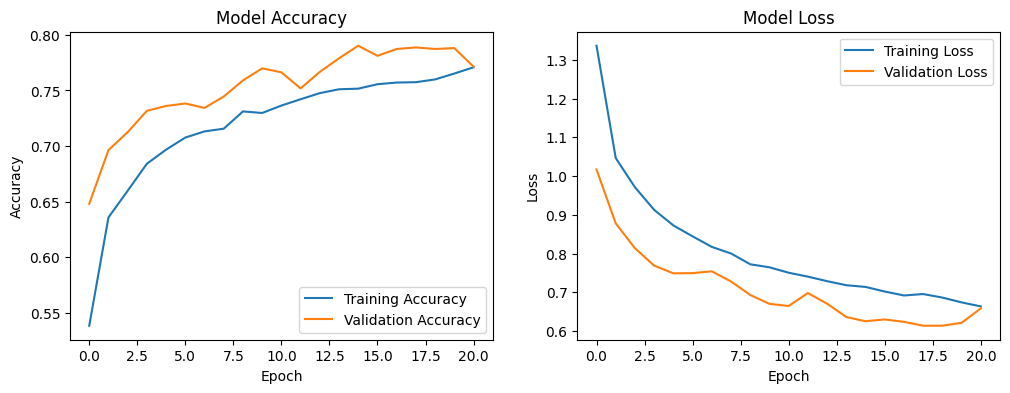

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

266/266 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


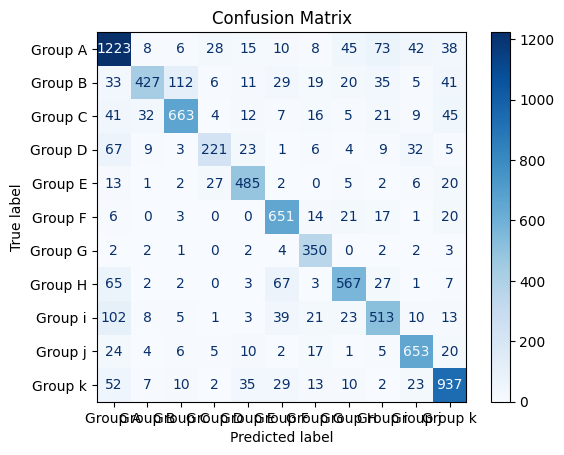

Number of incorrect predictions: 1792


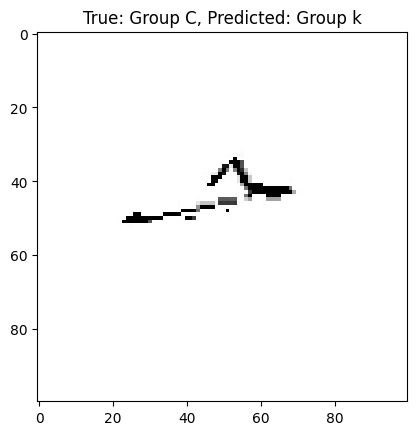

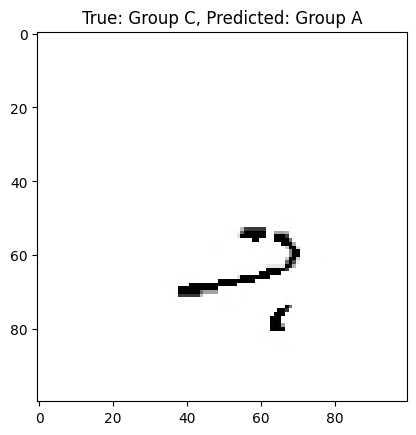

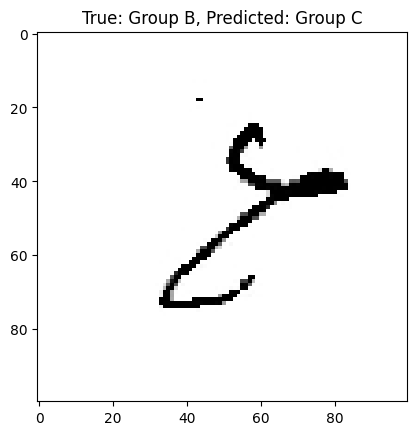

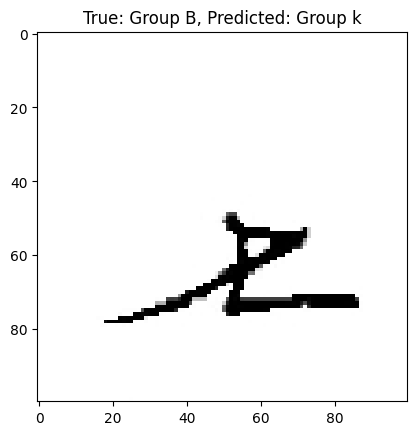

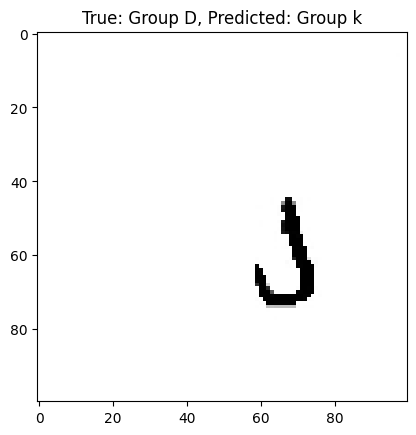

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(os.listdir(data_dir)))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

incorrect = np.where(y_pred != y_true)[0]
print(f"Number of incorrect predictions: {len(incorrect)}")

if len(incorrect) > 0:
    random_indices = np.random.choice(incorrect, size=min(5, len(incorrect)), replace=False)
    for idx in random_indices:
        plt.imshow(x_test[idx].reshape(100, 100), cmap='gray')
        plt.title(f"True: {sorted(os.listdir(data_dir))[y_true[idx]]}, Predicted: {sorted(os.listdir(data_dir))[y_pred[idx]]}")
        plt.show()
else:
    print("No incorrect predictions to display.")


### reduce DropOut and epochs

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.02,
    height_shift_range=0.02,
    shear_range=0.15,
    zoom_range=0.2,
    fill_mode='nearest'
)

train_generator = datagen.flow(x_train, y_train, batch_size=35)

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, GlobalAveragePooling2D, Dropout

input_layer = Input(shape=(100, 100, 1))

x = Conv2D(3, (3, 3), padding="same", activation="relu")(input_layer)
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(100, 100, 3))
x = base_model(x)

x = GlobalAveragePooling2D()(x)
x = Dropout(0.1)(x)  
x = Dense(128, activation="relu")(x)
output_layer = Dense(11, activation="softmax")(x)

model = Model(inputs=input_layer, outputs=output_layer)

for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

print(model.summary())


<ipython-input-22-744afa2b8cae>:9: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(100, 100, 3))


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)          │ (None, 100, 100, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 100, 100, 3)         │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 4, 4, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_4           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 11)                  │           1,419 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,423,401 (9.24 MB)

 Trainable params: 165,417 (646.16 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

None


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'character_recognition_model_MobileNet.keras',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1
)
history = model.fit(
    train_generator,
    epochs=28,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/28
969/970 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4835 - loss: 1.5041
Epoch 1: val_accuracy improved from -inf to 0.61978, saving model to character_recognition_model_MobileNet.keras
970/970 ━━━━━━━━━━━━━━━━━━━━ 68s 60ms/step - accuracy: 0.4837 - loss: 1.5036 - val_accuracy: 0.6198 - val_loss: 1.0798
Epoch 2/28
970/970 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6456 - loss: 1.0159
Epoch 2: val_accuracy improved from 0.61978 to 0.65315, saving model to character_recognition_model_MobileNet.keras
970/970 ━━━━━━━━━━━━━━━━━━━━ 43s 44ms/step - accuracy: 0.6456 - loss: 1.0159 - val_accuracy: 0.6531 - val_loss: 1.0026
Epoch 3/28
970/970 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6752 - loss: 0.9269
Epoch 3: val_accuracy improved from 0.65315 to 0.67425, saving model to character_recognition_model_MobileNet.keras
970/970 ━━━━━━━━━━━━━━━━━━━━ 43s 44ms/step - accuracy: 0.6753 - loss: 0.9269 - val_accuracy: 0.6743 - val_loss: 0.9359
Epoch 4/28
970/970 ━━━━━━━━━━━━━━━━━━

In [ ]:
train_loss = history.history['loss'][-1]
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Training Loss: {train_loss:.4f}")
print(f"Test Loss: {test_loss:.4f}")

train_accuracy = history.history['accuracy'][-1]
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


Training Loss: 0.6674
Test Loss: 0.7201
Training Accuracy: 76.94%
Test Accuracy: 75.56%


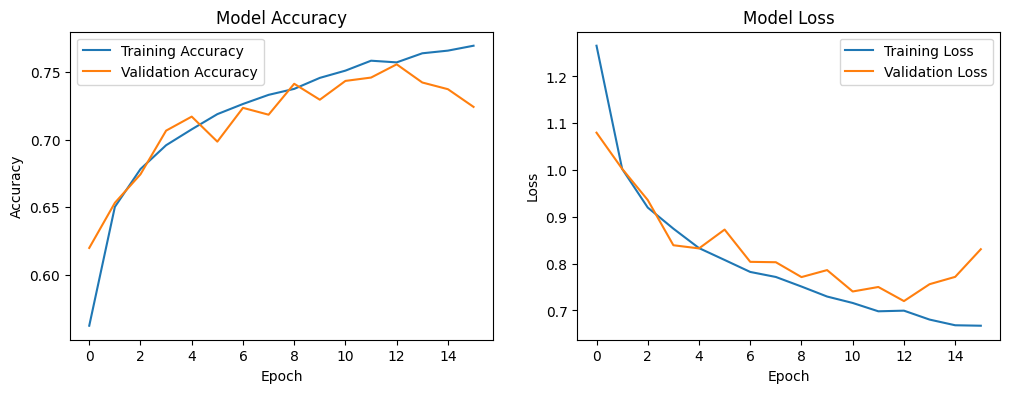

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

266/266 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step


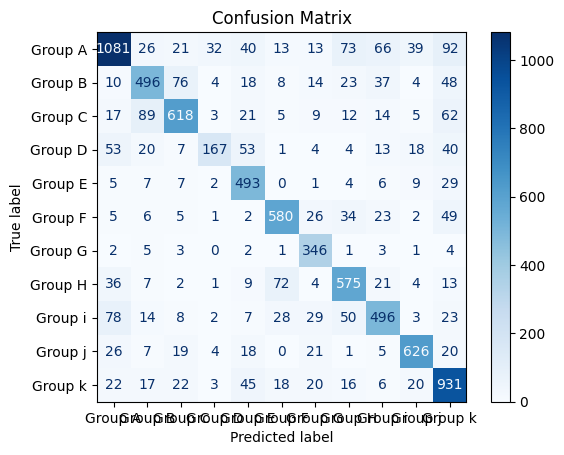

Number of incorrect predictions: 2073


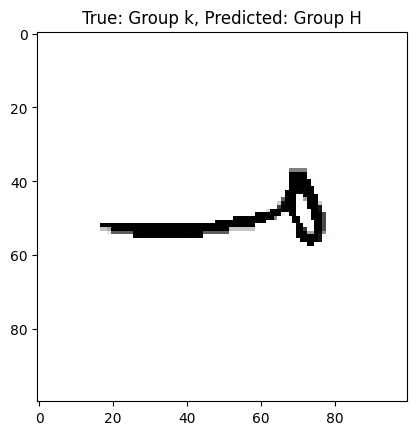

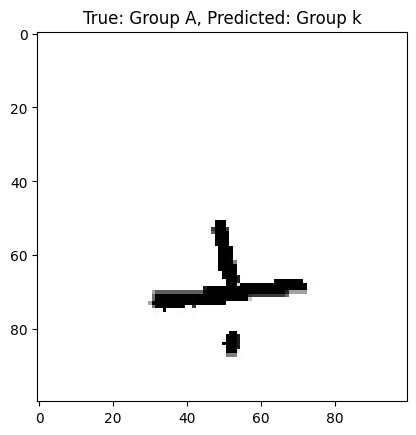

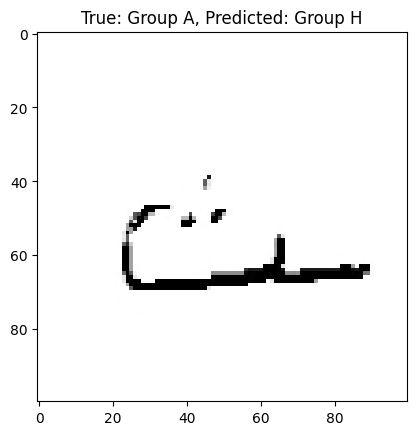

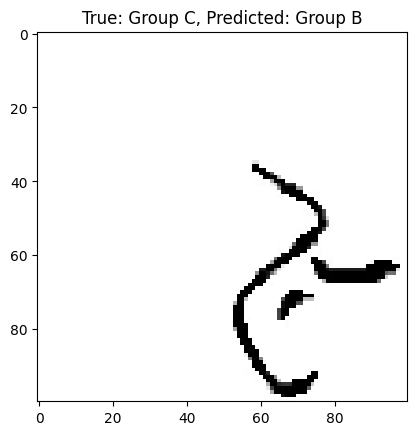

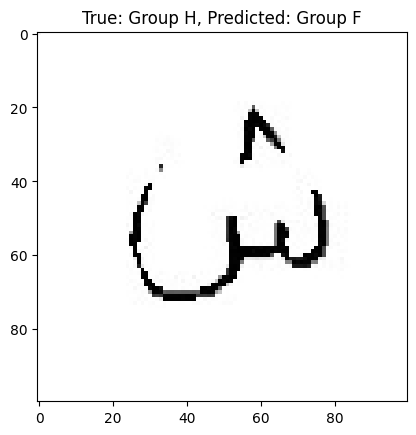

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(os.listdir(data_dir)))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

incorrect = np.where(y_pred != y_true)[0]
print(f"Number of incorrect predictions: {len(incorrect)}")

if len(incorrect) > 0:
    random_indices = np.random.choice(incorrect, size=min(5, len(incorrect)), replace=False)
    for idx in random_indices:
        plt.imshow(x_test[idx].reshape(100, 100), cmap='gray')
        plt.title(f"True: {sorted(os.listdir(data_dir))[y_true[idx]]}, Predicted: {sorted(os.listdir(data_dir))[y_pred[idx]]}")
        plt.show()
else:
    print("No incorrect predictions to display.")


### more training

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'character_recognition_model_MobileNet.keras',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1
)
history = model.fit(
    train_generator,
    epochs=28,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/28
969/970 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7640 - loss: 0.6859
Epoch 1: val_accuracy improved from -inf to 0.74982, saving model to character_recognition_model_MobileNet.keras
970/970 ━━━━━━━━━━━━━━━━━━━━ 44s 45ms/step - accuracy: 0.7640 - loss: 0.6859 - val_accuracy: 0.7498 - val_loss: 0.7385
Epoch 2/28
970/970 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7618 - loss: 0.6814
Epoch 2: val_accuracy did not improve from 0.74982
970/970 ━━━━━━━━━━━━━━━━━━━━ 42s 43ms/step - accuracy: 0.7618 - loss: 0.6814 - val_accuracy: 0.7483 - val_loss: 0.7366
Epoch 3/28
970/970 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7708 - loss: 0.6520
Epoch 3: val_accuracy did not improve from 0.74982
970/970 ━━━━━━━━━━━━━━━━━━━━ 46s 47ms/step - accuracy: 0.7708 - loss: 0.6520 - val_accuracy: 0.7479 - val_loss: 0.7281
Epoch 4/28
969/970 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7726 - loss: 0.6539
Epoch 4: val_accuracy did not improve from 0.74982
970/970 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
train_loss = history.history['loss'][-1]
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Training Loss: {train_loss:.4f}")
print(f"Test Loss: {test_loss:.4f}")

train_accuracy = history.history['accuracy'][-1]
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


Training Loss: 0.6145
Test Loss: 0.7054
Training Accuracy: 78.54%
Test Accuracy: 75.57%


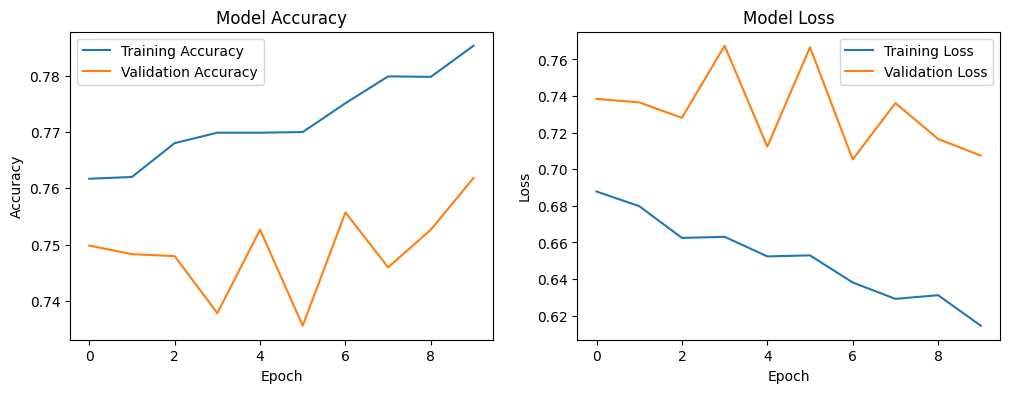

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

266/266 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


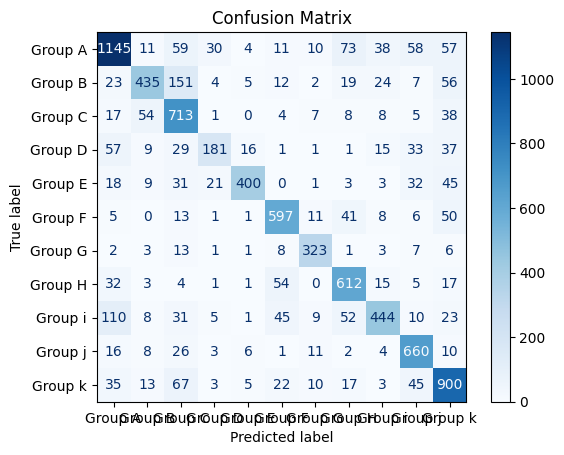

Number of incorrect predictions: 2072


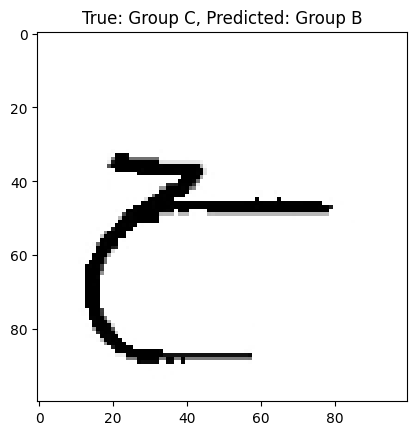

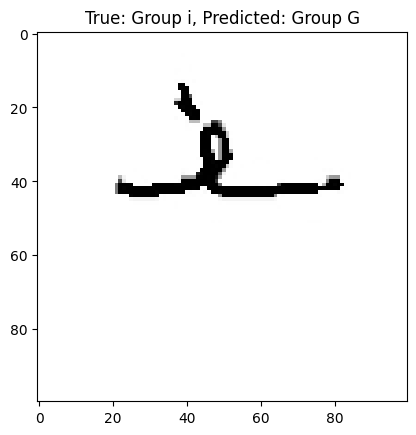

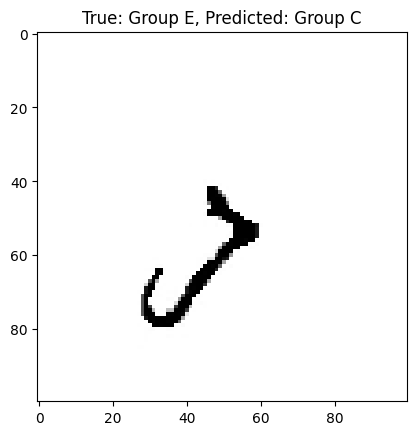

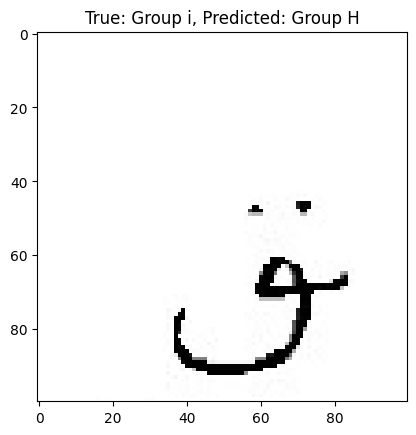

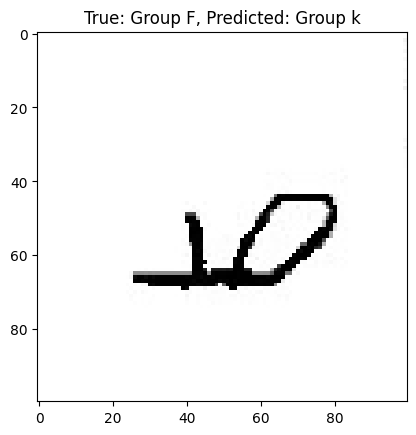

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(os.listdir(data_dir)))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

incorrect = np.where(y_pred != y_true)[0]
print(f"Number of incorrect predictions: {len(incorrect)}")

if len(incorrect) > 0:
    random_indices = np.random.choice(incorrect, size=min(5, len(incorrect)), replace=False)
    for idx in random_indices:
        plt.imshow(x_test[idx].reshape(100, 100), cmap='gray')
        plt.title(f"True: {sorted(os.listdir(data_dir))[y_true[idx]]}, Predicted: {sorted(os.listdir(data_dir))[y_pred[idx]]}")
        plt.show()
else:
    print("No incorrect predictions to display.")


### more training

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'character_recognition_model_MobileNet.keras',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1
)
history = model.fit(
    train_generator,
    epochs=25,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/25
969/970 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.7876 - loss: 0.6119
Epoch 1: val_accuracy improved from -inf to 0.77399, saving model to character_recognition_model_MobileNet.keras
970/970 ━━━━━━━━━━━━━━━━━━━━ 56s 57ms/step - accuracy: 0.7876 - loss: 0.6119 - val_accuracy: 0.7740 - val_loss: 0.6736
Epoch 2/25
970/970 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.7951 - loss: 0.5949
Epoch 2: val_accuracy did not improve from 0.77399
970/970 ━━━━━━━━━━━━━━━━━━━━ 57s 59ms/step - accuracy: 0.7951 - loss: 0.5949 - val_accuracy: 0.7529 - val_loss: 0.7442
Epoch 3/25
970/970 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.7993 - loss: 0.5903
Epoch 3: val_accuracy improved from 0.77399 to 0.78366, saving model to character_recognition_model_MobileNet.keras
970/970 ━━━━━━━━━━━━━━━━━━━━ 53s 55ms/step - accuracy: 0.7993 - loss: 0.5903 - val_accuracy: 0.7837 - val_loss: 0.6529
Epoch 4/25
970/970 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8022 - loss: 0.5759
Epoch 4: val_ac

In [ ]:
train_loss = history.history['loss'][-1]
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Training Loss: {train_loss:.4f}")
print(f"Test Loss: {test_loss:.4f}")

train_accuracy = history.history['accuracy'][-1]
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


Training Loss: 0.5360
Test Loss: 0.6431
Training Accuracy: 81.29%
Test Accuracy: 78.76%


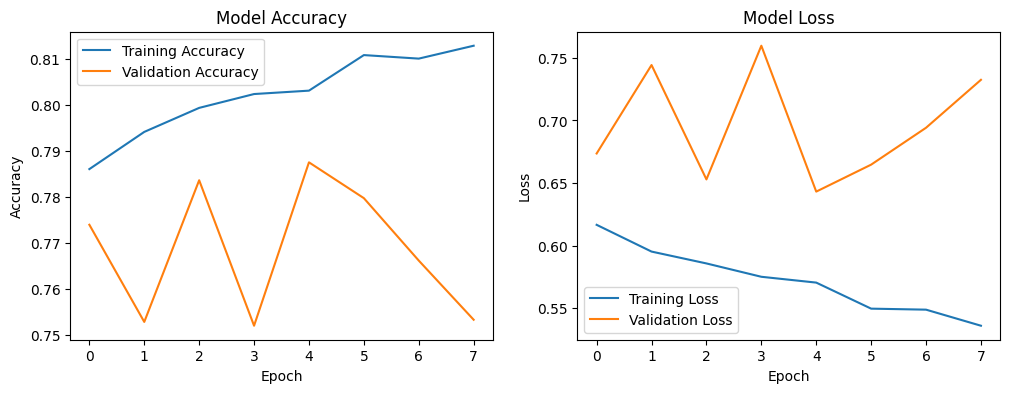

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

266/266 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step


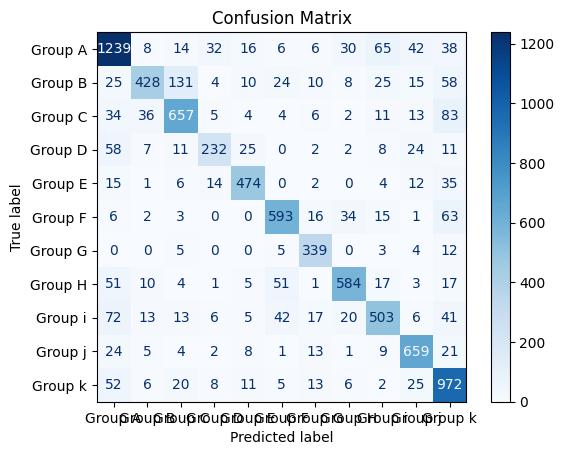

Number of incorrect predictions: 1802


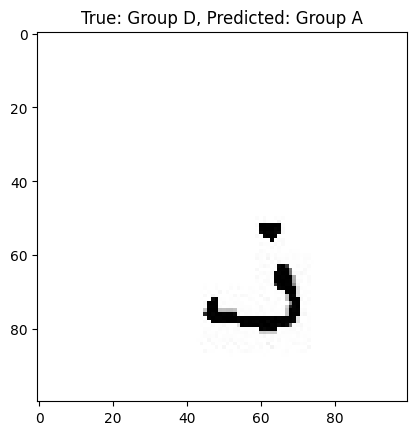

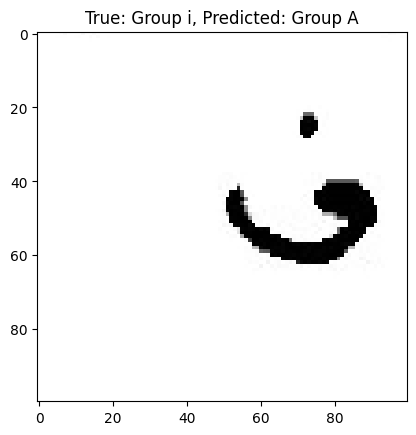

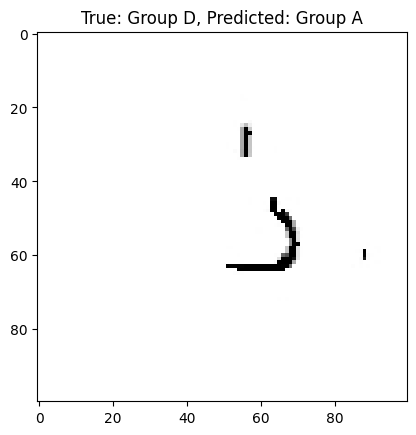

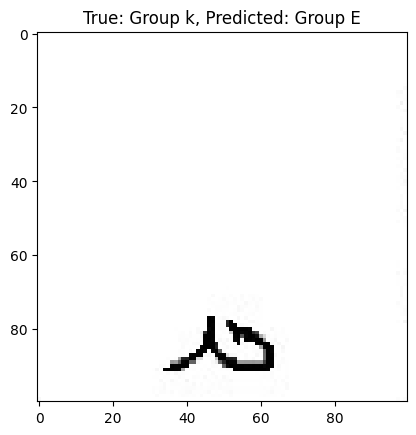

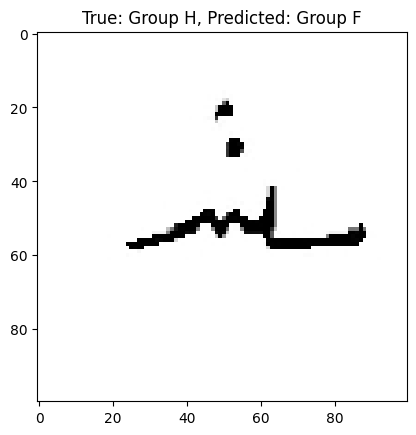

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(os.listdir(data_dir)))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

incorrect = np.where(y_pred != y_true)[0]
print(f"Number of incorrect predictions: {len(incorrect)}")

if len(incorrect) > 0:
    random_indices = np.random.choice(incorrect, size=min(5, len(incorrect)), replace=False)
    for idx in random_indices:
        plt.imshow(x_test[idx].reshape(100, 100), cmap='gray')
        plt.title(f"True: {sorted(os.listdir(data_dir))[y_true[idx]]}, Predicted: {sorted(os.listdir(data_dir))[y_pred[idx]]}")
        plt.show()
else:
    print("No incorrect predictions to display.")


### add Learning rate with 0.0001,
### فك تجميد اخر 10 طبقات
### اضافة dropOut


In [7]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam


input_layer = Input(shape=(100, 100, 1))

x = Conv2D(3, (3, 3), padding="same", activation="relu")(input_layer)
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(100, 100, 3))
x = base_model(x)

x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.4)(x)
output_layer = Dense(11, activation="softmax")(x)


model = Model(inputs=input_layer, outputs=output_layer)

for layer in base_model.layers[-10:]:
    layer.trainable = True


model.compile(optimizer=Adam(learning_rate=0.0001), loss="categorical_crossentropy", metrics=["accuracy"])

print(model.summary())


<ipython-input-7-843e3248c29d>:11: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(100, 100, 3))


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 100, 100, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 100, 100, 3)         │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 4, 4, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 11)                  │           1,419 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,423,401 (9.24 MB)

 Trainable params: 2,389,289 (9.11 MB)

 Non-trainable params: 34,112 (133.25 KB)

None


In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

train_generator = datagen.flow(x_train, y_train, batch_size=32)


In [9]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'character_recognition_model_MobileNet.keras',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1
)
history = model.fit(
    train_generator,
    epochs=25,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/25


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1061/1061 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.4281 - loss: 1.6680
Epoch 1: val_accuracy improved from -inf to 0.52405, saving model to character_recognition_model_MobileNet.keras
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 143s 86ms/step - accuracy: 0.4283 - loss: 1.6676 - val_accuracy: 0.5241 - val_loss: 1.4487
Epoch 2/25
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.7827 - loss: 0.6709
Epoch 2: val_accuracy improved from 0.52405 to 0.73049, saving model to character_recognition_model_MobileNet.keras
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 86s 55ms/step - accuracy: 0.7827 - loss: 0.6709 - val_accuracy: 0.7305 - val_loss: 0.8089
Epoch 3/25
1060/1061 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8290 - loss: 0.5319
Epoch 3: val_accuracy improved from 0.73049 to 0.87420, saving model to character_recognition_model_MobileNet.keras
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 58s 55ms/step - accuracy: 0.8290 - loss: 0.5318 - val_accuracy: 0.8742 - val_loss: 0.3631
Epoch 4/25
1060/1061 ━━━━━━━━━━━━━━

In [10]:
train_loss = history.history['loss'][-1]
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Training Loss: {train_loss:.4f}")
print(f"Test Loss: {test_loss:.4f}")

train_accuracy = history.history['accuracy'][-1]
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


Training Loss: 0.2849
Test Loss: 0.2317
Training Accuracy: 90.69%
Test Accuracy: 92.23%


266/266 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step


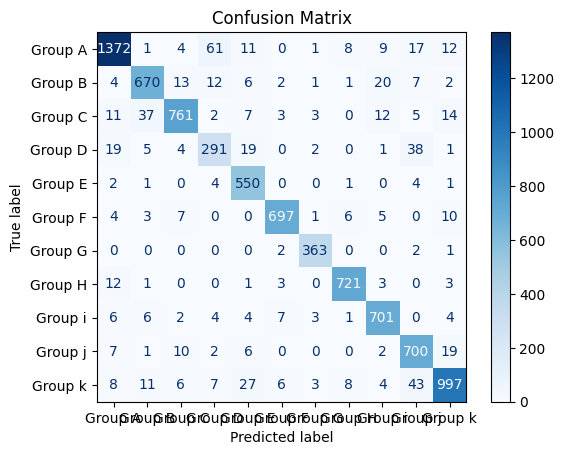

Number of incorrect predictions: 659


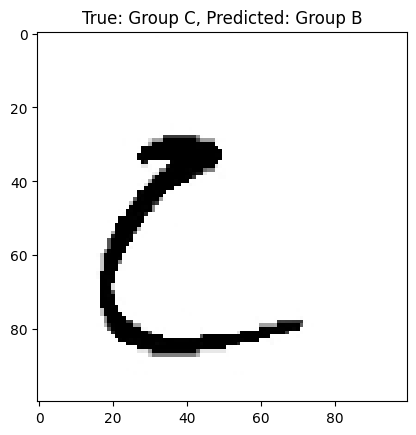

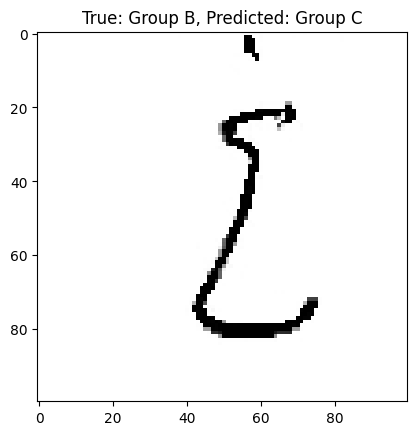

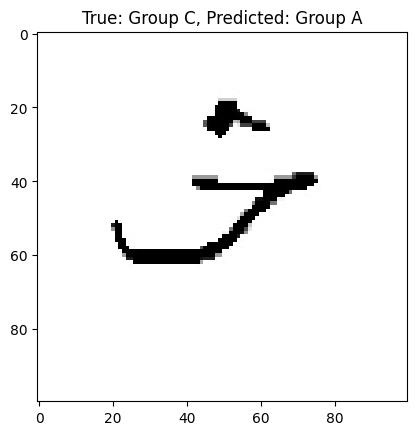

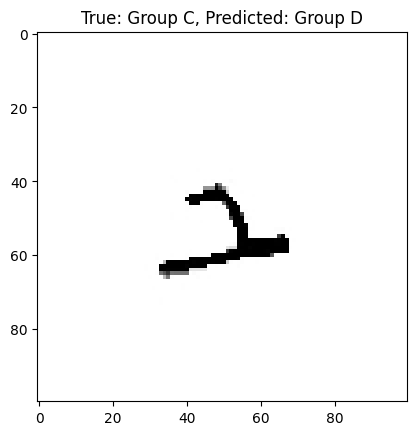

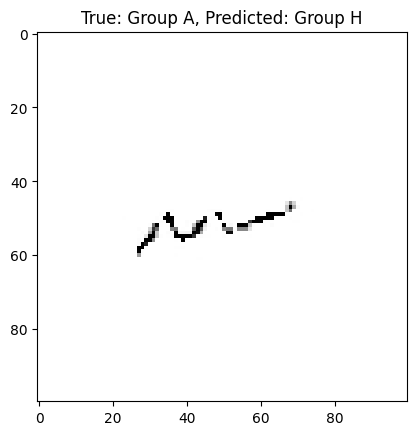

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(os.listdir(data_dir)))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

incorrect = np.where(y_pred != y_true)[0]
print(f"Number of incorrect predictions: {len(incorrect)}")

if len(incorrect) > 0:
    random_indices = np.random.choice(incorrect, size=min(5, len(incorrect)), replace=False)
    for idx in random_indices:
        plt.imshow(x_test[idx].reshape(100, 100), cmap='gray')
        plt.title(f"True: {sorted(os.listdir(data_dir))[y_true[idx]]}, Predicted: {sorted(os.listdir(data_dir))[y_pred[idx]]}")
        plt.show()
else:
    print("No incorrect predictions to display.")


### reduce dropOut

In [23]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

train_generator = datagen.flow(x_train, y_train, batch_size=32)


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam


input_layer = Input(shape=(100, 100, 1))

x = Conv2D(3, (3, 3), padding="same", activation="relu")(input_layer)
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(100, 100, 3))
x = base_model(x)

x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.1)(x)
output_layer = Dense(11, activation="softmax")(x)


model = Model(inputs=input_layer, outputs=output_layer)

for layer in base_model.layers[-10:]:
    layer.trainable = True


model.compile(optimizer=Adam(learning_rate=0.0001), loss="categorical_crossentropy", metrics=["accuracy"])

print(model.summary())


<ipython-input-24-e7d3f2765639>:11: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(100, 100, 3))


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)          │ (None, 100, 100, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 100, 100, 3)         │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 4, 4, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_5           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 11)                  │           1,419 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,423,401 (9.24 MB)

 Trainable params: 2,389,289 (9.11 MB)

 Non-trainable params: 34,112 (133.25 KB)

None


In [25]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'character_recognition_model_MobileNet.keras',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1
)
history = model.fit(
    train_generator,
    epochs=25,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.5097 - loss: 1.4299
Epoch 1: val_accuracy improved from -inf to 0.19488, saving model to character_recognition_model_MobileNet.keras
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 133s 77ms/step - accuracy: 0.5098 - loss: 1.4295 - val_accuracy: 0.1949 - val_loss: 3.8119
Epoch 2/25
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8083 - loss: 0.5758
Epoch 2: val_accuracy improved from 0.19488 to 0.70962, saving model to character_recognition_model_MobileNet.keras
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 94s 51ms/step - accuracy: 0.8083 - loss: 0.5758 - val_accuracy: 0.7096 - val_loss: 0.9148
Epoch 3/25
1060/1061 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8441 - loss: 0.4574
Epoch 3: val_accuracy improved from 0.70962 to 0.87939, saving model to character_recognition_model_MobileNet.keras
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 58s 55ms/step - accuracy: 0.8441 - loss: 0.4574 - val_accuracy: 0.8794 - val_loss: 0.3689
Epoch 4/25
1061/1061 ━━━

In [26]:
train_loss = history.history['loss'][-1]
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Training Loss: {train_loss:.4f}")
print(f"Test Loss: {test_loss:.4f}")

train_accuracy = history.history['accuracy'][-1]
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


Training Loss: 0.2537
Test Loss: 0.2358
Training Accuracy: 91.27%
Test Accuracy: 91.74%


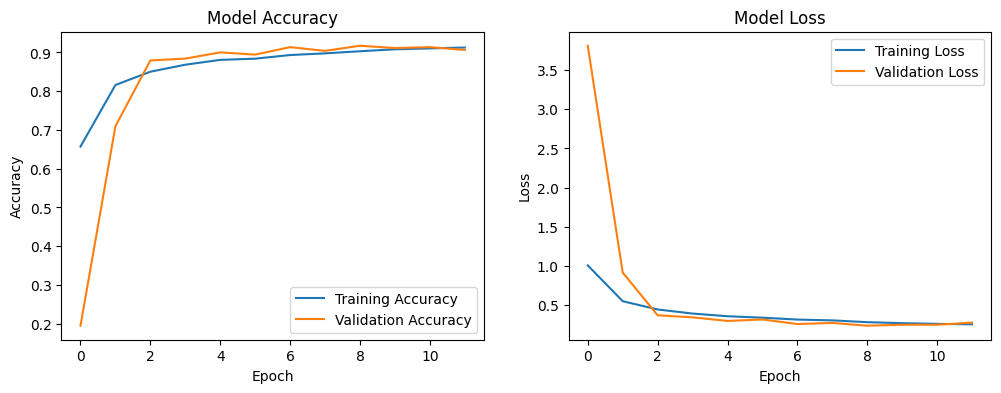

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

266/266 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step


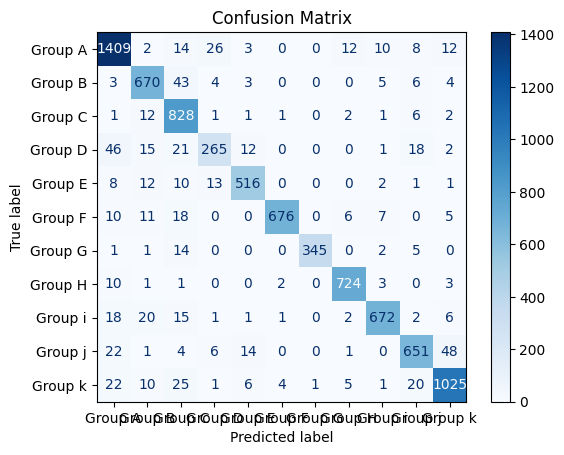

Number of incorrect predictions: 701


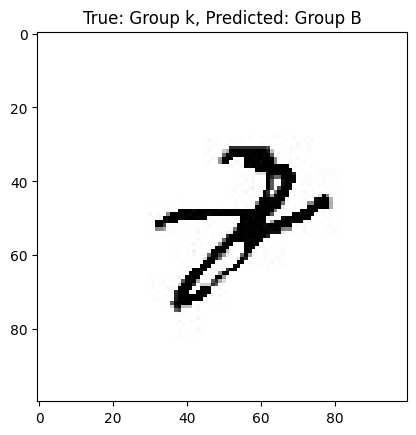

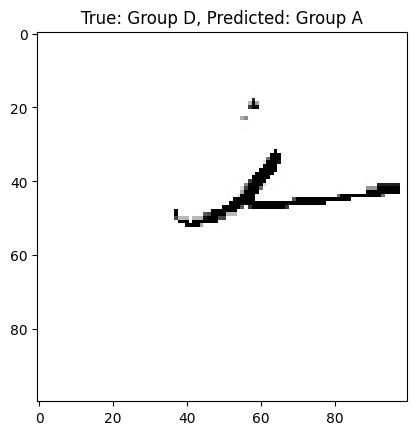

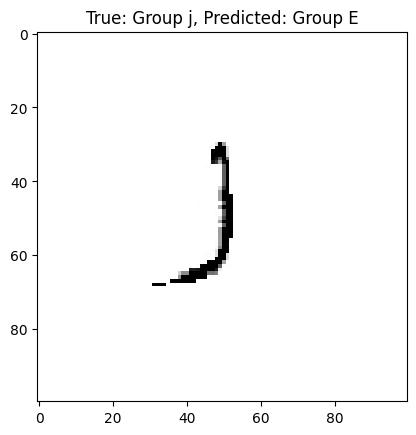

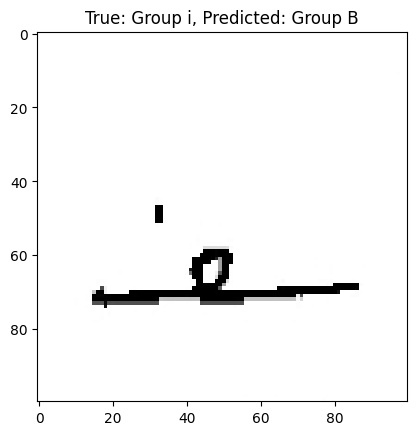

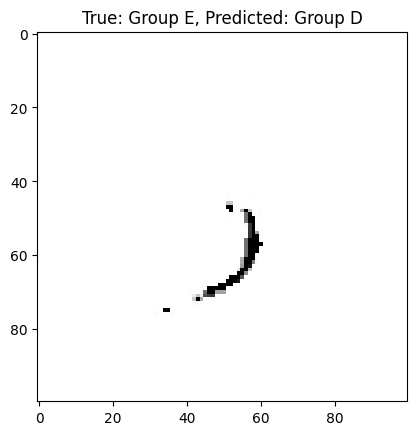

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(os.listdir(data_dir)))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

incorrect = np.where(y_pred != y_true)[0]
print(f"Number of incorrect predictions: {len(incorrect)}")

if len(incorrect) > 0:
    random_indices = np.random.choice(incorrect, size=min(5, len(incorrect)), replace=False)
    for idx in random_indices:
        plt.imshow(x_test[idx].reshape(100, 100), cmap='gray')
        plt.title(f"True: {sorted(os.listdir(data_dir))[y_true[idx]]}, Predicted: {sorted(os.listdir(data_dir))[y_pred[idx]]}")
        plt.show()
else:
    print("No incorrect predictions to display.")


### Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Predicted Character: 3


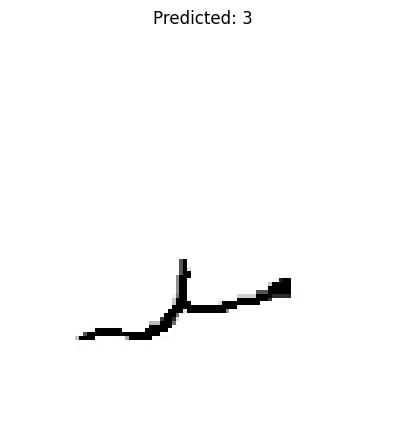

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

test_image_path = '/content/experience 3/Group D/Dal_End/AHCR_00004_Dal_End_38.jpg'

image = cv2.imread(test_image_path, cv2.IMREAD_GRAYSCALE)

if image is not None:
    image = cv2.resize(image, (100, 100))
    image_rgb = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    image_rgb = image_rgb / 255.0
    image_rgb = np.expand_dims(image_rgb, axis=0)

    prediction = model.predict(image_rgb)

    predicted_class = np.argmax(prediction, axis=1)[0]

    print(f"Predicted Character: {predicted_class}")

    plt.figure(figsize=(5, 5))
    plt.imshow(image, cmap='gray')
    plt.title(f"Predicted: {predicted_class}")
    plt.axis('off')
    plt.show()
else:
    print("Error: Unable to load the image. Please check the file path.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Predicted Group: Group D
Predicted Character: Dal_Isolated


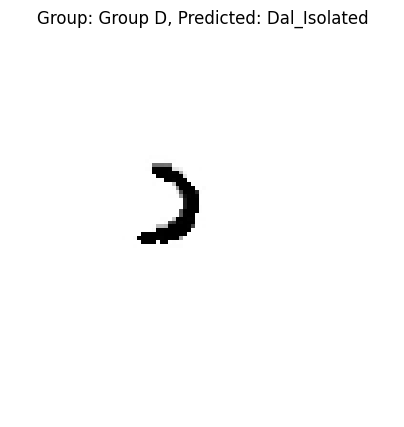

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

test_image_path = '/content/experience 3/Group D/Dal_Isolated/AHCR_00002_Dal_Isolated_44.jpg'

group_name = os.path.basename(os.path.dirname(os.path.dirname(test_image_path)))  
predicted_character_name = os.path.basename(os.path.dirname(test_image_path))  

image = cv2.imread(test_image_path, cv2.IMREAD_GRAYSCALE)

if image is not None:
    image = cv2.resize(image, (100, 100))
    image_rgb = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    image_rgb = image_rgb / 255.0
    image_rgb = np.expand_dims(image_rgb, axis=0)

    prediction = model.predict(image_rgb)

    predicted_class = np.argmax(prediction, axis=1)[0]

    print(f"Predicted Group: {group_name}")
    print(f"Predicted Character: {predicted_character_name}")

    plt.figure(figsize=(5, 5))
    plt.imshow(image, cmap='gray')
    plt.title(f"Group: {group_name}, Predicted: {predicted_character_name}")
    plt.axis('off')
    plt.show()
else:
    print("Error: Unable to load the image. Please check the file path.")


In [29]:
model.save("mobileNet.keras")